In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import ListedColormap, BoundaryNorm, LinearSegmentedColormap, Normalize
from mpl_toolkits.mplot3d.art3d import Line3DCollection
import torch
import dnnlib.util_v5 as util
from tqdm import tqdm
import pickle
from matplotlib.ticker import FuncFormatter
import gc
from PIL import Image

import numpy as np
import pickle
import os
import re 
import json 
import click
import torch
from torch_utils import distributed as dist
from training import toy_training_loop_vfm_noDataGen
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib import colors
from plot_neural import *
from plot_sim_results_v5 import *
from plot_sim_results_img_v5 import * 
from plot_musal_v5 import * 
import pickle, types
from torch_utils import persistence

import pandas as pd

import warnings
warnings.filterwarnings('ignore', 'Grad strides do not match bucket view strides') # False warning 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_device(device)
colorgrad = "PuOr"

# 2. read data

In [2]:
folder_data = 'out/musal_behavior/dim3_lag5/data'
folder = 'out/musal_behavior/dim3_lag5/t_1'
chk_pts = '/network-snapshot-070246.pkl' # '/network-snapshot-210739.pkl'
useCov = False

dim_to_keep = 3

In [3]:
pkl_path = folder + chk_pts

In [4]:
dataset_samples = np.load(folder_data + "/dataset_samples.npz", allow_pickle=True)
cov_static_samples = np.load(folder_data + "/cov_static_trunc_only.npz", allow_pickle=True)

In [5]:
dset_samples = to_list_of_arrays(dataset_samples['samples'])
cov_stat_samples = to_list_of_arrays(cov_static_samples['samples'])
mean_img = np.load('data/musal_behavior/mean_image.npy')

In [6]:
dset_samples[0].shape

(71937, 1, 64, 64)

In [33]:
mean_img.shape

(64, 64)

In [34]:
# # no clamp
# clamp_range = None

# # version 1: global clamp (results are similar)
# eps = 1e-2
# min_value = min(np.min(arr) for arr in dset_samples)
# max_value = max(np.max(arr) for arr in dset_samples)
# clamp_range = np.array([min_value - eps, max_value + eps], dtype=np.float32) # give some space

# version 2: clamp dim-by-dim (results are similar)
eps = 1e-2
T_max = max(a.shape[0] for a in dset_samples)
padded = [np.pad(a, ((0, T_max-a.shape[0]), (0,0), (0,0), (0,0)), mode='constant', constant_values=np.nan)
          for a in dset_samples]                                              # -> (n_trial, T_max, C, H, W)
stacked = np.stack(padded, axis=0)
min_img = np.nanmin(stacked, axis=(0,1))                                      # shape (C,H,W)
max_img = np.nanmax(stacked, axis=(0,1))                                      # shape (C,H,W)
clamp_range = np.stack([min_img - eps, max_img + eps], axis=0).astype(np.float32)  # shape (2,C,H,W)

# 3. read model

In [8]:
# with open(pkl_path, 'rb') as f:
#     model_all = pickle.load(f)
# if 'ema' in model_all: net = model_all['ema']  # EMA-stabilized model (recommended for inference/simulation)
# else: net = model_all['net']  # Raw trained model
# flow_net = net.unet_model  # Compressive flow (u_theta)
# dyn_net = net.vnet_model   # Dynamics flow (v_theta)
# encoder = net.encoder
if not hasattr(persistence, "_orig_reconstruct"):
    persistence._orig_reconstruct = persistence._reconstruct_persistent_obj
def _tolerant_reconstruct(meta):
    try:
        return persistence._orig_reconstruct(meta)
    except Exception:
        class _Stub: pass
        return _Stub()

class PatchedUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if module == "torch_utils.persistence" and name == "_reconstruct_persistent_obj":
            return _tolerant_reconstruct
        return super().find_class(module, name)

with open(pkl_path, "rb") as f:
    model_all = PatchedUnpickler(f).load()

# use the net; ignore any loss_fn in the pickle
net = model_all["ema"] if "ema" in model_all else model_all["net"]
flow_net = net.unet_model
dyn_net   = net.vnet_model
encoder   = net.encoder

In [9]:
lag = infer_lag_k_from_dyn_net(dyn_net)

# 4. Projected latent

In [10]:
is_image = (np.asarray(dset_samples[0]).ndim == 4)
if is_image:
    _, C, H, W = np.asarray(dset_samples[0]).shape
T_min = min(arr.shape[0] for arr in dset_samples)
T_max = max(arr.shape[0] for arr in dset_samples)
n_step = T_max//10
dset_samples_look = [dset_samples[0][:n_step]]

In [11]:
gc.collect()
torch.cuda.empty_cache()
latent_traj_list = proj_to_latent(dset_samples_look, flow_net.to(device), 0.0, device, chunk_size = 1024)
gc.collect()
torch.cuda.empty_cache()

In [12]:
mu_traj_sim, d, L, loading = latent_mu(latent_traj_list, encoder.to(device), dim_to_keep, device, fullRes = True)

In [13]:
d[0:10]

tensor([1.5124e+00, 1.5006e+00, 1.3688e-01, 1.2160e-12, 1.0444e-12, 1.0674e-12,
        9.6100e-13, 1.0506e-12, 1.1000e-12, 8.5531e-13], device='cuda:0')

Text(0.5, 0.98, 'flowed latent trajc for each trial')

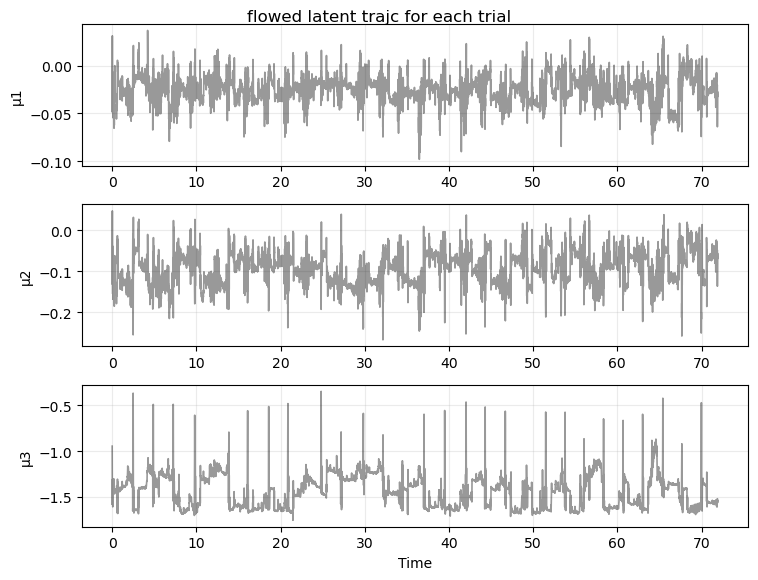

In [14]:
mu_traj_sim_np = [mu_traj_sim[j].cpu().numpy() for j in range(len(mu_traj_sim))]
plot_latent_time_series(mu_traj_sim_np, alpha = 0.4, dims=np.arange(dim_to_keep), 
                        dt=0.01, labels=None)
plt.suptitle('flowed latent trajc for each trial')

(<Figure size 600x600 with 2 Axes>,
 <Axes: title={'center': 'Flowed Latent trajectories'}, xlabel='μ1', ylabel='μ2'>)

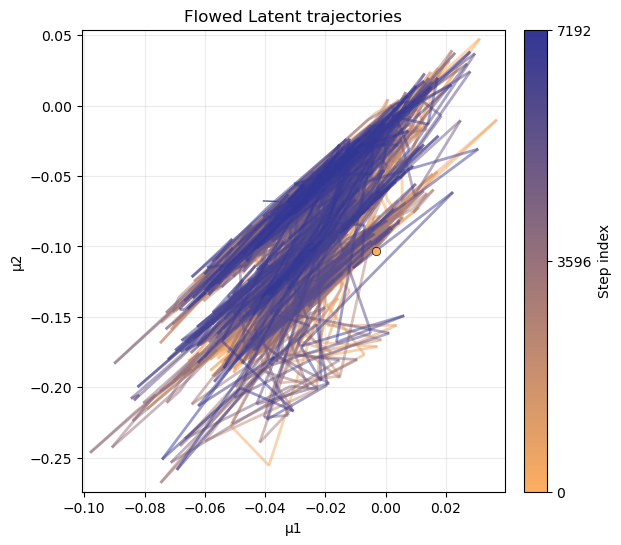

In [43]:
plot_mu_trajectories_gradient_steps_2d(
    mu_traj_sim_np,
    trial_indices=np.arange(len(mu_traj_sim_np)), 
    dims=(0,1),
    title="Flowed Latent trajectories",
)

# 4. Latent

## 4.1 outliers?

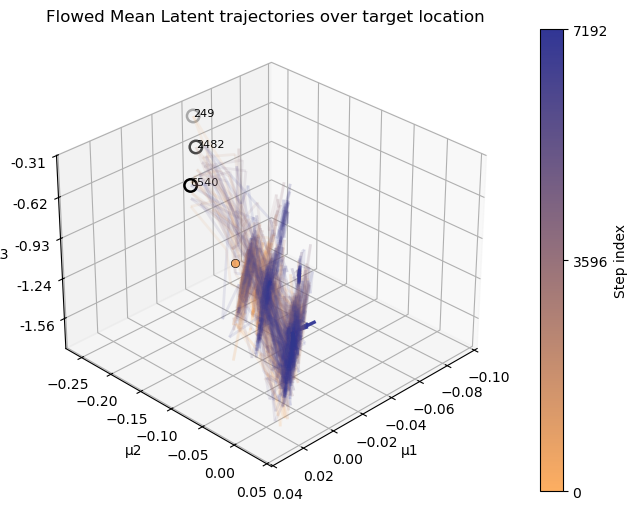

In [42]:
scale = scale_factor_like_plot(mu_traj_sim, np.arange(len(mu_traj_sim)), dims=(0,1,2), z_scale='auto')
k = 3
x0 = mu_traj_sim[0]                    # torch.Size([4000, 3])
mu = x0.mean(dim=0)
dists = torch.linalg.norm(x0 - mu, dim=1)
topk = torch.topk(dists, k=k)         # largest distances
topk_idx = topk.indices.cpu()         # <-- indices you asked for

plot_mu_trajectories_gradient_steps_3d(
    mu_traj_sim,
    labels=None,
    trial_indices=np.arange(len(mu_traj_sim)), 
    dims=(0,1,2),
    alpha=0.1,
    title="Flowed Mean Latent trajectories over target location",
    z_scale='auto',  # Automatically scales z to be visually comparable to x and y
    aspect_ratio=(1, 1, 1),
    circmap = colorgrad,
    elev_azim = (30, 45), # (20,45)
)

ax = plt.gca()  # the function’s axes are current
x0_np = x0.detach().cpu().numpy()
ii = topk_idx.numpy()
ax.scatter(
    x0_np[ii, 0], x0_np[ii, 1], x0_np[ii, 2] * scale,
    s=80, marker='o', facecolors='none', edgecolors='k', linewidths=1.8, zorder=10
)

for j in ii: ax.text(x0_np[j,0], x0_np[j,1], x0_np[j,2]*scale, str(j), fontsize=8)
plt.draw()

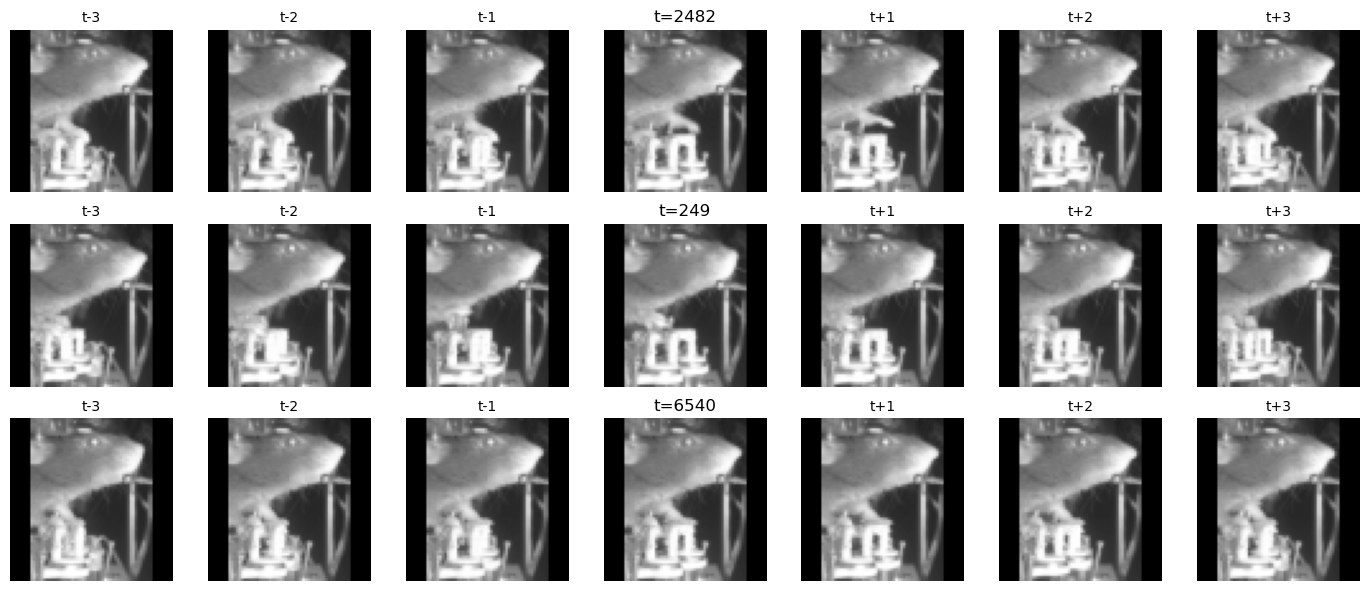

In [59]:
X = mu_traj_sim[0].detach().cpu().numpy()
coords = {i: (X[i,0], X[i,1], X[i,2]) for i in topk_idx}
plot_selected_image(topk_idx, dset_samples_look, mean_img, h = 3,
                    coords=coords, row_color= 'tab:blue')
# plt.tight_layout()
# plt.show()

In [52]:
coords

{tensor(2482): (-0.015304342, -0.19335072, -0.3514351),
 tensor(249): (-0.038734097, -0.2556993, -0.3709296),
 tensor(6540): (0.006122399, -0.14915313, -0.42601088)}

## 4.2 3 bands?

In [63]:
x0 = mu_traj_sim[0]
labels, _, n, centers = find_bands_by_projection(x0, K=3, scale_z=scale)

m = 3 # or 3
idx_sets = reps_for_all_bands_onband(x0, labels, n, centers, K=3,
                                     m=m, scale_z=scale, keep_q=0.30, trim=0.1)
print({"band_indices": idx_sets})

{'band_indices': [[1104, 3085, 1220], [361, 4276, 7047], [5474, 6980, 1590]]}


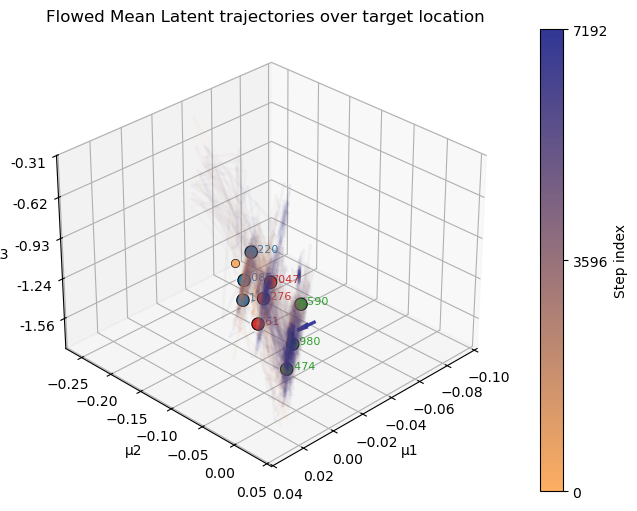

In [64]:
plot_mu_trajectories_gradient_steps_3d(
    mu_traj_sim,
    labels=None,
    trial_indices=np.arange(len(mu_traj_sim)), 
    dims=(0,1,2),
    alpha=0.03,
    title="Flowed Mean Latent trajectories over target location",
    z_scale='auto',  # Automatically scales z to be visually comparable to x and y
    aspect_ratio=(1, 1, 1),
    circmap = colorgrad,
    elev_azim = (30, 45), # (20,45)
)

ax = plt.gca()
X  = x0.detach().cpu().numpy()
cols = ['tab:blue','tab:red','tab:green'][:len(idx_sets)]
for idxs, col in zip(idx_sets, cols):
    if not idxs: continue
    ii = np.asarray(idxs, int)
    ax.scatter(X[ii,0], X[ii,1], X[ii,2]*scale, s=100, facecolors='white',
               edgecolors='white', linewidths=2.0, zorder=12)
    ax.scatter(X[ii,0], X[ii,1], X[ii,2]*scale, s=80, facecolors=col,
               edgecolors='k', linewidths=0.8, alpha=0.98, zorder=13)
    for j in ii:
        ax.text(X[j,0], X[j,1], X[j,2]*scale, f"{j}", fontsize=8, color=col)
plt.draw()

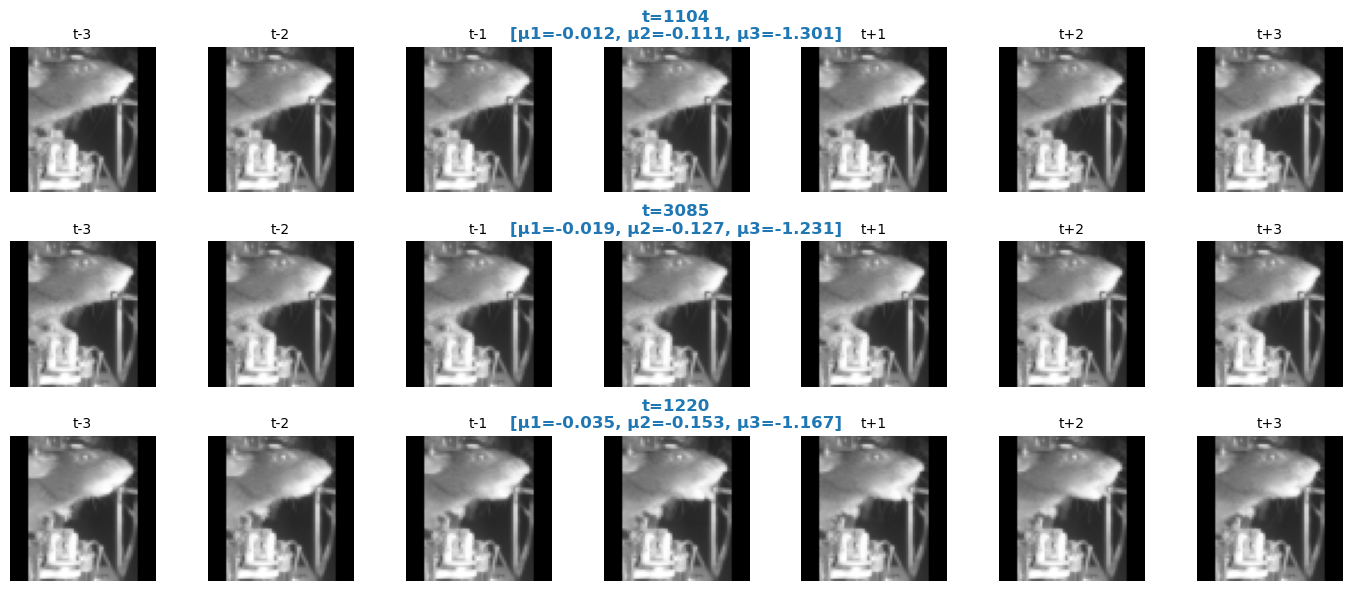

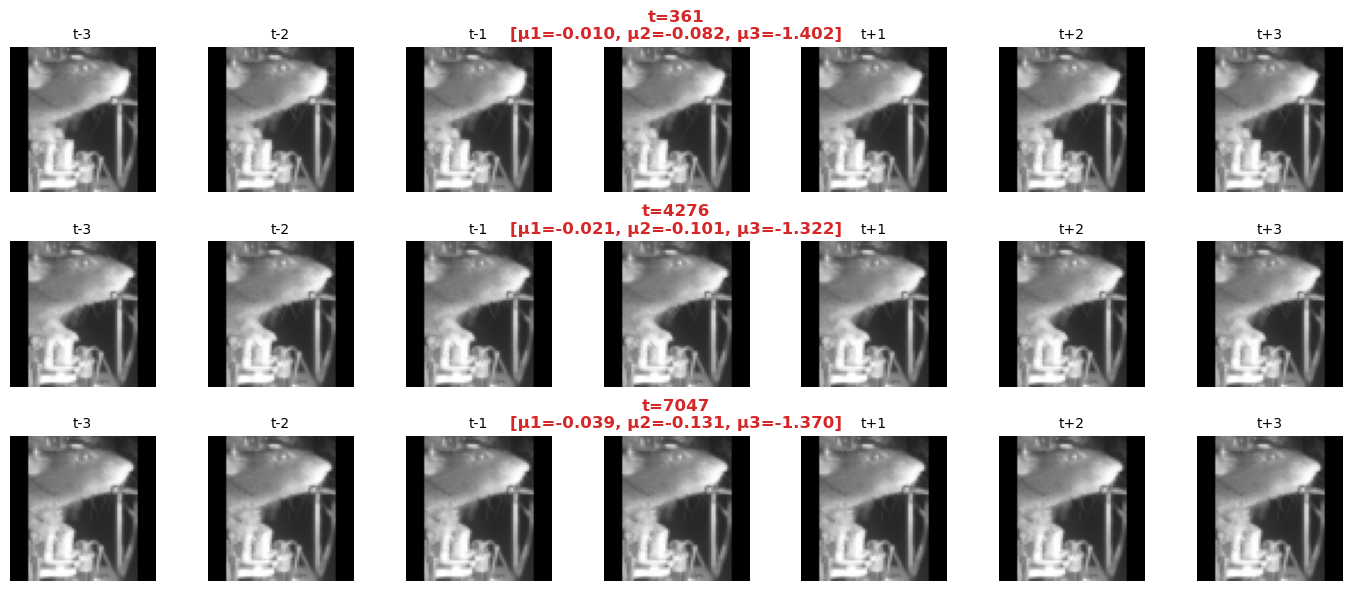

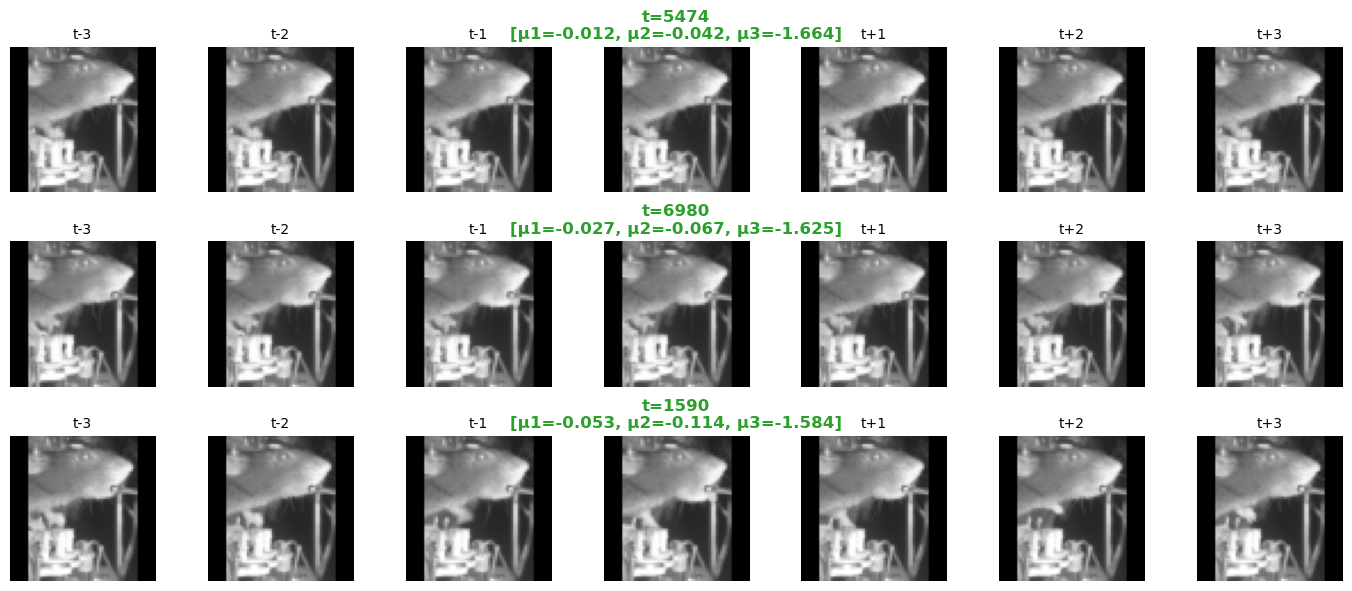

In [65]:
X = x0.detach().cpu().numpy()
band_colors = ['tab:blue','tab:red','tab:green']
for b, idxs in enumerate(idx_sets):
    coords = {i: (X[i,0], X[i,1], X[i,2]) for i in idxs}
    plot_selected_image(idxs, dset_samples_look, mean_img, h=3,
                        coords=coords, row_color=band_colors[b])

## 4.3 influence of each coordiante?